In [1]:
# pyvirtualdisplay 없이 바로 렌더링
import gymnasium as gym
import highway_env

env = gym.make('roundabout-v0', render_mode='rgb_array')
print(env.observation_space.shape)
print(env.action_space.n)
obs, _ = env.reset()
frame = env.render()  # 화면 없이 numpy array로 반환
print(frame.shape)    # (H, W, 3) 이면 성공

(5, 5)
5


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


(600, 600, 3)


In [2]:
# 셀 1 - pyvirtualdisplay 제거, 환경변수만 설정
import sys
import os

sys.path.insert(0, '/mnt/hdd/hyeonseo/workspace/dreamerv3')

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

os.environ['JAX_PLATFORMS'] = 'cuda'
# os.environ['LD_LIBRARY_PATH'] = (
#     '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
#     'site-packages/nvidia/cublas/lib:'
#     '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
#     'site-packages/nvidia/cusolver/lib:'
#     '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
#     'site-packages/nvidia/cusparse/lib:'
#     '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
#     'site-packages/nvidia/cufft/lib:'
#     '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/'
#     'site-packages/nvidia/cudnn/lib:'
#     '/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib'
# )

import jax
print('JAX devices:', jax.devices())

JAX devices: [cuda(id=0)]


In [3]:
import elements

# 기존 YAML 읽기 부분을 대체하는 하드코딩된 파이썬 딕셔너리
config_dict = {
    "loss_scales": {
        "rec": 1.0, "rew": 1.0, "con": 1.0, "dyn": 1.0,
        "rep": 0.1, "policy": 1.0, "value": 1.0, "repval": 0.3
    },
    "opt": {
        "lr": 4e-05, "agc": 0.3, "eps": 1e-20, "beta1": 0.9,
        "beta2": 0.999, "momentum": True, "wd": 0.0,
        "schedule": "const", "warmup": 1000, "anneal": 0
    },
    "ac_grads": False,
    "dyn": {
        "typ": "rssm",
        "rssm": {
            "deter": 2048, "hidden": 256, "stoch": 32, "classes": 16,
            "act": "silu", "norm": "rms", "unimix": 0.01,
            "outscale": 1.0, "winit": "trunc_normal_in",
            "imglayers": 2, "obslayers": 1, "dynlayers": 1,
            "absolute": False, "blocks": 8, "free_nats": 1.0
        }
    },
    "enc": {
        "typ": "simple",
        "simple": {
            "depth": 16, "mults": [2, 3, 4, 4], "layers": 3,
            "units": 256, "act": "silu", "norm": "rms",
            "winit": "trunc_normal_in", "symlog": True,
            "outer": False, "kernel": 5, "strided": False
        }
    },
    "dec": {
        "typ": "simple",
        "simple": {
            "depth": 16, "mults": [2, 3, 4, 4], "layers": 3,
            "units": 256, "act": "silu", "norm": "rms",
            "outscale": 1.0, "winit": "trunc_normal_in",
            "outer": False, "kernel": 5, "bspace": 8, "strided": False
        }
    },
    "rewhead": {
        "layers": 1, "units": 256, "act": "silu", "norm": "rms",
        "output": "symexp_twohot", "outscale": 0.0,
        "winit": "trunc_normal_in", "bins": 255
    },
    "conhead": {
        "layers": 1, "units": 256, "act": "silu", "norm": "rms",
        "output": "binary", "outscale": 1.0, "winit": "trunc_normal_in"
    },
    "policy": {
        "layers": 3, "units": 256, "act": "silu", "norm": "rms",
        "minstd": 0.1, "maxstd": 1.0, "outscale": 0.01,
        "unimix": 0.01, "winit": "trunc_normal_in"
    },
    "value": {
        "layers": 3, "units": 256, "act": "silu", "norm": "rms",
        "output": "symexp_twohot", "outscale": 0.0,
        "winit": "trunc_normal_in", "bins": 255
    },
    "policy_dist_disc": "categorical",
    "policy_dist_cont": "bounded_normal",
    "imag_last": 0,
    "imag_length": 15,
    "horizon": 333,
    "contdisc": True,
    "imag_loss": {"slowtar": False, "lam": 0.95, "actent": 0.0003, "slowreg": 1.0},
    "repl_loss": {"slowtar": False, "lam": 0.95, "slowreg": 1.0},
    "slowvalue": {"rate": 0.02, "every": 1},
    "retnorm": {"impl": "perc", "rate": 0.01, "limit": 1.0, "perclo": 5.0, "perchi": 95.0, "debias": False},
    "valnorm": {"impl": "none", "rate": 0.01, "limit": 1e-08},
    "advnorm": {"impl": "none", "rate": 0.01, "limit": 1e-08},
    "reward_grad": True,
    "repval_loss": True,
    "repval_grad": True,
    "report": True,
    "report_gradnorms": False,
    "logdir": "logdir/highway_roundabout",
    "seed": 0,
    "jax": {
        "platform": "cuda", "compute_dtype": "bfloat16",
        "policy_devices": [0], "train_devices": [0],
        "mock_devices": 0, "prealloc": True, "jit": True,
        "debug": False, "expect_devices": 0, "enable_policy": True,
        "coordinator_address": ""
    },
    "batch_size": 16,
    "batch_length": 64,
    "replay_context": 1,
    "report_length": 32,
    "replica": 0,
    "replicas": 1
}

config =elements.Config(
    config_dict
)

In [4]:
# 셀 2 - 환경 + 에이전트 로드
import gymnasium as gym
import highway_env
import numpy as np
import imageio
import pathlib
import elements
import ruamel.yaml as yaml
from dreamerv3.agent import Agent
from huggingface_hub import snapshot_download
from dreamerv3.agent import Agent

# ==========================================
# 단계 1: 허깅페이스에서 복잡한 인증 없이 바로 다운로드
# ==========================================
REPO_ID = "HyunseoYun/dreamerv3-custom-envs"
DOWNLOAD_DIR = "./dreamerv3_checkpoints"

print(f"Hugging Face에서 체크포인트 다운로드 중... (로그인 필요 없음)")
# Public 레포지토리이므로 token 인자나 로그인 과정이 전혀 필요 없습니다.
# snapshot_download(repo_id=REPO_ID, local_dir=DOWNLOAD_DIR)
print("이전 완료!")

# 에이전트 초기화
obs_space = {
    "obs": elements.Space(np.float32, env.observation_space.shape),
    "reward": elements.Space(np.float32),
    "is_first": elements.Space(bool),
    "is_last": elements.Space(bool),
    "is_terminal": elements.Space(bool),
}
act_space = {"action": elements.Space(np.int32, (), 0, env.action_space.n)}

agent = Agent(obs_space, act_space, config)

# 체크포인트 로드 부분 수정 - load_or_save 대신 load만 사용
cp = elements.Checkpoint(pathlib.Path(DOWNLOAD_DIR) / 'checkpoints/highway_roundabout')
cp.agent = agent

# 체크포인트 존재 확인
ckpt_dir = pathlib.Path(DOWNLOAD_DIR) / 'checkpoints/highway_roundabout'
print("ckpt 폴더 내용:")
for f in ckpt_dir.iterdir():
    print(f)

# load만 실행 (save 안 함)
cp.load()
print("체크포인트 로드 완료!")

/mnt/hdd/hyeonseo/.conda/envs/dreamerv3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hugging Face에서 체크포인트 다운로드 중... (로그인 필요 없음)
이전 완료!
Observations
  obs              Space(float32, shape=(5, 5), low=-inf, high=inf)
  reward           Space(float32, shape=(), low=-inf, high=inf)
  is_first         Space(bool, shape=(), low=False, high=True)
  is_last          Space(bool, shape=(), low=False, high=True)
  is_terminal      Space(bool, shape=(), low=False, high=True)
Actions
  action           Space(int32, shape=(), low=0, high=5)
Extras
  consec           Space(int32, shape=(), low=-2147483648, high=2147483647)
  stepid           Space(uint8, shape=(20,), low=0, high=255)
  dyn/deter        Space(float32, shape=(2048,), low=-inf, high=inf)
  dyn/stoch        Space(float32, shape=(32, 16), low=-inf, high=inf)
JAX devices (1): [cuda:0]
Policy devices: cuda:0
Train devices:  cuda:0
Initializing parameters...
Optimizer opt has 9,736,477 params:
     5,782,784 dyn
       853,503 val
       794,393 dec
       789,253 pol
       721,407 rew
       656,129 con
       139,008 enc

In [7]:
# 셀 3 - 추론 + GIF 저장
env = gym.make('roundabout-v0', render_mode='rgb_array',config={"duration": 100})
frames = []
obs_raw, _ = env.reset()
done = False
total_reward = 0
carry = agent.init_policy(1)
is_first = True

while not done:
    frame = env.render()
    frames.append(frame)

    obs = {
        "obs": np.array([obs_raw], dtype=np.float32),        # (1, 5, 5)
        "reward": np.array([0.0], dtype=np.float32),          # (1,)
        "is_first": np.array([is_first]),                     # (1,)
        "is_last": np.array([False]),                         # (1,)
        "is_terminal": np.array([False]),                     # (1,)
    }
    is_first = False

    carry, act, _ = agent.policy(carry, obs, mode='eval')
    action = int(act['action'][0])
    obs_raw, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated

env.close()
print(f"총 점수: {total_reward:.2f}, 프레임 수: {len(frames)}")

imageio.mimsave('highway_roundabout_inference.gif', frames, fps=10)
print("GIF 저장 완료!")

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


총 점수: 85.33, 프레임 수: 100
GIF 저장 완료!


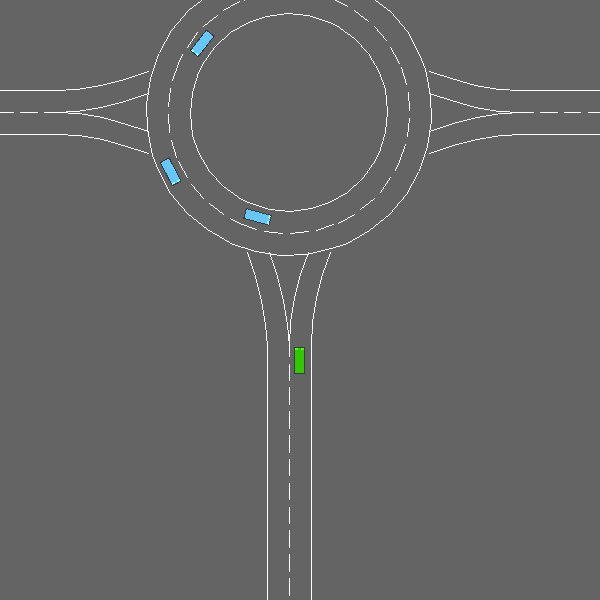

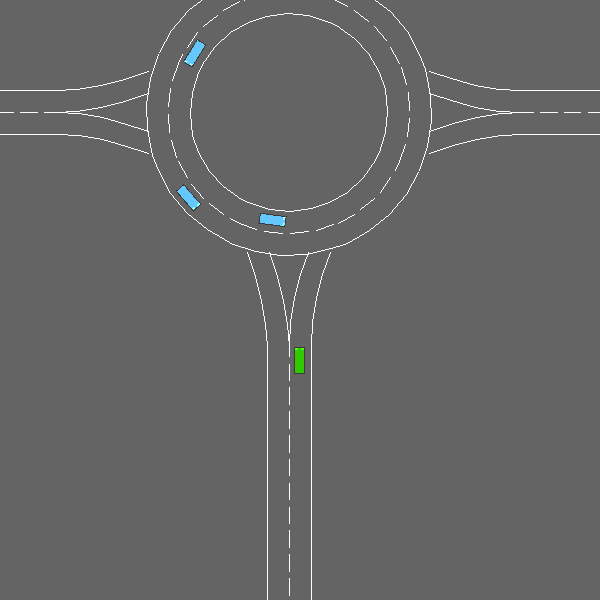

In [ ]:
# 셀 4 - 노트북에서 바로 보기
from IPython.display import Image
Image('highway_roundabout_inference.gif')